<a href="https://colab.research.google.com/github/chaymaebouabdellah24-tech/SunPath-Predictor/blob/main/SunPath_Predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
#Installer XGBoost
!pip install xgboost

In [8]:
#Importer les librairies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor

In [9]:
#Charger les datasets
generation = pd.read_csv('Plant_1_Generation_Data.csv')
weather = pd.read_csv('Plant_1_Weather_Sensor_Data.csv')

In [10]:
#Explorer les données
generation.head()
weather.head()

,DATE_TIME,PLANT_ID,SOURCE_KEY,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15 00:00:00,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
1,2020-05-15 00:15:00,4135001,HmiyD2TTLFNqkNe,25.084589,22.761668,0.0
2,2020-05-15 00:30:00,4135001,HmiyD2TTLFNqkNe,24.935753,22.592306,0.0
3,2020-05-15 00:45:00,4135001,HmiyD2TTLFNqkNe,24.846130,22.360852,0.0
4,2020-05-15 01:00:00,4135001,HmiyD2TTLFNqkNe,24.621525,22.165423,0.0


In [11]:
#Convertir les dates
generation['DATE_TIME'] = pd.to_datetime(generation['DATE_TIME'])
weather['DATE_TIME'] = pd.to_datetime(weather['DATE_TIME'])

/tmp/ipykernel_4308/1030277924.py:2: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  generation['DATE_TIME'] = pd.to_datetime(generation['DATE_TIME'])


In [12]:
#faire le megre
data = pd.merge(generation, weather, on='DATE_TIME', how='inner')

print(data.shape)

(68774, 12)


In [13]:
#Vérifier le dataset final
data.head()
data.shape

(68774, 12)

In [14]:
#Convertir la date
data['DATE_TIME'] = pd.to_datetime(data['DATE_TIME'])

In [15]:
#Créer des variables temporelles
data['hour'] = data['DATE_TIME'].dt.hour
data['day'] = data['DATE_TIME'].dt.day
data['month'] = data['DATE_TIME'].dt.month

In [16]:
#Choisir les variables (features)
X = data[['IRRADIATION',
          'AMBIENT_TEMPERATURE',
          'MODULE_TEMPERATURE',
          'hour']]

In [17]:
#Variable cible
y = data['AC_POWER']

In [18]:
#Séparer Train / Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [19]:
#Linear Regression
lr = LinearRegression()

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

In [20]:
#Evaluation Linear Regression
print("Linear Regression")

print("MAE:", mean_absolute_error(y_test, pred_lr))
print("R2:", r2_score(y_test, pred_lr))

Linear Regression
MAE: 26.2979657748521
R2: 0.9800290556767175


In [21]:
#Random Forest
rf = RandomForestRegressor()

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

In [22]:
#Evaluation Random Forest
print("Random Forest")

print("MAE:", mean_absolute_error(y_test, pred_rf))
print("R2:", r2_score(y_test, pred_rf))

Random Forest
MAE: 16.37268760330034
R2: 0.9864721280825584


In [23]:
#XGBoost
xgb = XGBRegressor()

xgb.fit(X_train, y_train)

pred_xgb = xgb.predict(X_test)

In [24]:
#Evaluation XGBoost
print("XGBoost")

print("MAE:", mean_absolute_error(y_test, pred_xgb))
print("R2:", r2_score(y_test, pred_xgb))

XGBoost
MAE: 16.633382073934325
R2: 0.986531205412942


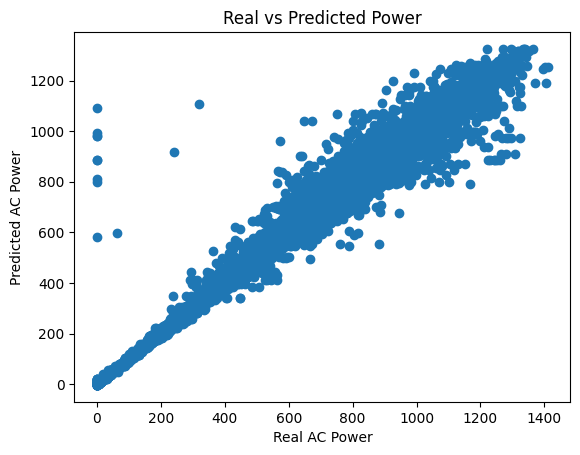

In [25]:
#Visualiser les prédictions
plt.scatter(y_test, pred_xgb)
plt.xlabel("Real AC Power")
plt.ylabel("Predicted AC Power")
plt.title("Real vs Predicted Power")
plt.show()

In [26]:
#Import Deep Learning
import numpy as np
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM
from sklearn.preprocessing import MinMaxScaler

In [27]:
#Normaliser les données
scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(X)

In [28]:
#Transformer les données en séquences
def create_sequences(X, y, time_steps=10):

    Xs = []
    ys = []

    for i in range(len(X) - time_steps):
        Xs.append(X[i:(i + time_steps)])
        ys.append(y.iloc[i + time_steps])

    return np.array(Xs), np.array(ys)

X_seq, y_seq = create_sequences(pd.DataFrame(X_scaled), y)

In [29]:
#Split Train/Test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_seq, y_seq, test_size=0.2, random_state=42
)

In [30]:
#Modèle RNN
model_rnn = Sequential()

model_rnn.add(SimpleRNN(50, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])))
model_rnn.add(Dense(1))

model_rnn.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model_rnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 50)             │         2,750 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,801 (10.94 KB)

 Trainable params: 2,801 (10.94 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
#Entrainer le modèle RNN
history_rnn = model_rnn.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/10
1720/1720 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 15512.0928 - mae: 56.5662 - val_loss: 7697.6753 - val_mae: 39.0317
Epoch 2/10
1720/1720 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 8173.1313 - mae: 41.6259 - val_loss: 7443.6973 - val_mae: 39.8270
Epoch 3/10
1720/1720 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 8018.7944 - mae: 41.0849 - val_loss: 7722.2065 - val_mae: 40.4001
Epoch 4/10
1720/1720 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 7912.9180 - mae: 40.6049 - val_loss: 6947.0376 - val_mae: 37.8987
Epoch 5/10
1720/1720 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 7748.1846 - mae: 40.0850 - val_loss: 9248.5059 - val_mae: 48.1429
Epoch 6/10
1720/1720 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 7637.0430 - mae: 39.8403 - val_loss: 8057.7451 - val_mae: 43.5809
Epoch 7/10
1720/1720 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - loss: 7475.1299 - mae: 39.3434 - val_loss: 6529.0762 - val_mae: 36.6470
Epoch 8/10
1720/1720 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 7375.0068 - mae: 39.0035 - val_loss: 641

In [32]:
#Modèle LSTM
model_lstm = Sequential()

model_lstm.add(LSTM(50, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])))
model_lstm.add(Dense(1))

model_lstm.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model_lstm.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        11,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,051 (43.17 KB)

 Trainable params: 11,051 (43.17 KB)

 Non-trainable params: 0 (0.00 B)

In [33]:
#Entrainer le modèle LSTM
history_lstm = model_lstm.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/10
1720/1720 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 17057.1953 - mae: 57.8852 - val_loss: 7174.8740 - val_mae: 39.5120
Epoch 2/10
1720/1720 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 7614.0239 - mae: 39.9571 - val_loss: 7163.2061 - val_mae: 38.5139
Epoch 3/10
1720/1720 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - loss: 7396.3730 - mae: 39.3221 - val_loss: 8125.5342 - val_mae: 44.3644
Epoch 4/10
1720/1720 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - loss: 7361.8154 - mae: 39.2992 - val_loss: 7716.8569 - val_mae: 42.6508
Epoch 5/10
1720/1720 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - loss: 7037.8638 - mae: 38.0854 - val_loss: 6081.9346 - val_mae: 34.4144
Epoch 6/10
1720/1720 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - loss: 6820.1265 - mae: 37.3757 - val_loss: 5923.2817 - val_mae: 34.0112
Epoch 7/10
1720/1720 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - loss: 6619.0498 - mae: 36.3993 - val_loss: 5997.8008 - val_mae: 35.0279
Epoch 8/10
1720/1720 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - loss: 6371.2461 - mae: 35.4518 - val_lo

In [34]:
#Faire une prédiction
predictions = model_lstm.predict(X_test)

print(predictions[:10])

430/430 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
[[ 1.1841200e+03]
 [ 2.9664120e+02]
 [ 6.5813092e+02]
 [ 3.8390201e+02]
 [ 1.0755365e+03]
 [ 1.7887050e+02]
 [-7.4800074e-02]
 [ 3.2770743e+02]
 [ 1.7761108e-01]
 [ 4.4651598e-01]]


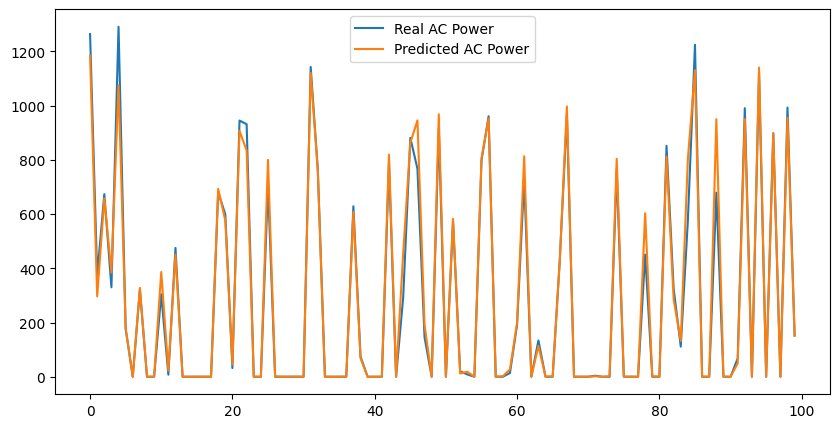

In [35]:
#Graphique pour la soutenance
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(y_test[:100], label="Real AC Power")
plt.plot(predictions[:100], label="Predicted AC Power")

plt.legend()
plt.show()

In [36]:
# =========================
# 🔮 PREDICTION FINALE (TOUS LES MODELES)
# =========================

import numpy as np

# 👉 1. Entrée (modifie si tu veux)
temp = 30
sun = 800
hum = 20

new_data = [[temp, sun, hum]]

print("📥 Données entrées :", new_data)

# =========================
# 👉 2. MODELES ML
# =========================

# Random Forest
try:
    print("🌳 Random Forest :", rf.predict(new_data))
except:
    print("RF non dispo")

# Linear Regression
try:
    print("📈 Linear Regression :", lr.predict(new_data))
except:
    print("LR non dispo")

# Decision Tree
try:
    print("🌲 Decision Tree :", dt.predict(new_data))
except:
    print("DT non dispo")

# XGBoost
try:
    print("🚀 XGBoost :", xgb.predict(new_data))
except:
    print("XGBoost non dispo")


# =========================
# 👉 3. MODELES DEEP LEARNING
# =========================

# 🔥 préparation pour RNN / LSTM
try:
    new_data_scaled = scaler.transform(new_data)
    new_data_scaled = np.reshape(new_data_scaled, (1, 1, new_data_scaled.shape[1]))
except:
    print("Erreur scaling")

# LSTM
try:
    print("🤖 LSTM :", model_lstm.predict(new_data_scaled))
except:
    print("LSTM non dispo")

# RNN
try:
    print("🧠 RNN :", model_rnn.predict(new_data_scaled))
except:
    print("RNN non dispo")


# =========================
# 🎯 FIN
# =========================

📥 Données entrées : [[30, 800, 20]]
RF non dispo
LR non dispo
DT non dispo
XGBoost non dispo
Erreur scaling
LSTM non dispo
RNN non dispo


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
